# Annual DWT probabilities

Load the saved DWT model and show the probability of each weather type by calendar year. Probabilities use the number of valid classified days as denominator; missing years remain blank and absent DWTs within observed years have probability zero.


In [1]:
from pathlib import Path
import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl").is_file()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from climate_services.probabilistic.MUSCLE.utils.awt_plotting import (
    plot_annual_probabilities, plot_annual_anomalies, plot_pca_modes,
    plot_year_clusters, plot_pc_pairs, plot_awt_centroids, plot_awt_anomalies,
)

dwt_path = repo_root / "climate_services/probabilistic/MUSCLE/outputs/dwt_model.pkl"
with dwt_path.open("rb") as f:
    dwt_model = pickle.load(f)

print(f"Loaded {dwt_model.num_clusters} DWTs from {dwt_path.name}")


Loaded 36 DWTs from dwt_model.pkl


In [2]:
# Keep the model's original DWT numbering (1..36).
dwt_daily = dwt_model.kma_bmus["kma_bmus"].copy()
dwt_daily.index = pd.DatetimeIndex(pd.to_datetime(dwt_daily.index)).normalize()
dwt_daily = dwt_daily.dropna().sort_index()
if dwt_daily.empty or dwt_daily.index.has_duplicates:
    raise ValueError("Expected one DWT per day and a non-empty classified record.")
dwt_ids = pd.Index(range(1, dwt_model.num_clusters + 1), name="DWT")
if not dwt_daily.isin(dwt_ids).all():
    raise ValueError("DWT labels do not match the saved model's 1-based numbering.")
years = pd.Index(range(dwt_daily.index.year.min(), dwt_daily.index.year.max() + 1), name="Year")
annual_counts = pd.crosstab(dwt_daily.index.year, dwt_daily).reindex(
    index=years, columns=dwt_ids, fill_value=0,
)
valid_days = annual_counts.sum(axis=1)
annual_probability = annual_counts.div(valid_days.replace(0, np.nan), axis=0)
# Cumulative frequency pools all classified days from the start through each year.
cumulative_counts = annual_counts.cumsum()
cumulative_probability = cumulative_counts.div(
    cumulative_counts.sum(axis=1).replace(0, np.nan), axis=0,
).where(valid_days.gt(0), axis=0)
np.testing.assert_allclose(annual_probability.loc[valid_days.gt(0)].sum(axis=1), 1)
np.testing.assert_allclose(cumulative_probability.loc[valid_days.gt(0)].sum(axis=1), 1)
print(f"{len(dwt_daily):,} classified days: {dwt_daily.index.min().date()} to {dwt_daily.index.max().date()}")


17,167 classified days: 1979-01-01 to 2025-12-31


Each panel shows one calendar year, using a 6 × 6 grid of DWT probabilities and the same Blues color scale across all years. DWTs are arranged in their original numeric order, from left to right and top to bottom (1–36); this is a cluster layout, not a geographic map. Numbers inside cells identify the DWT. Each annual panel sums to 100%.


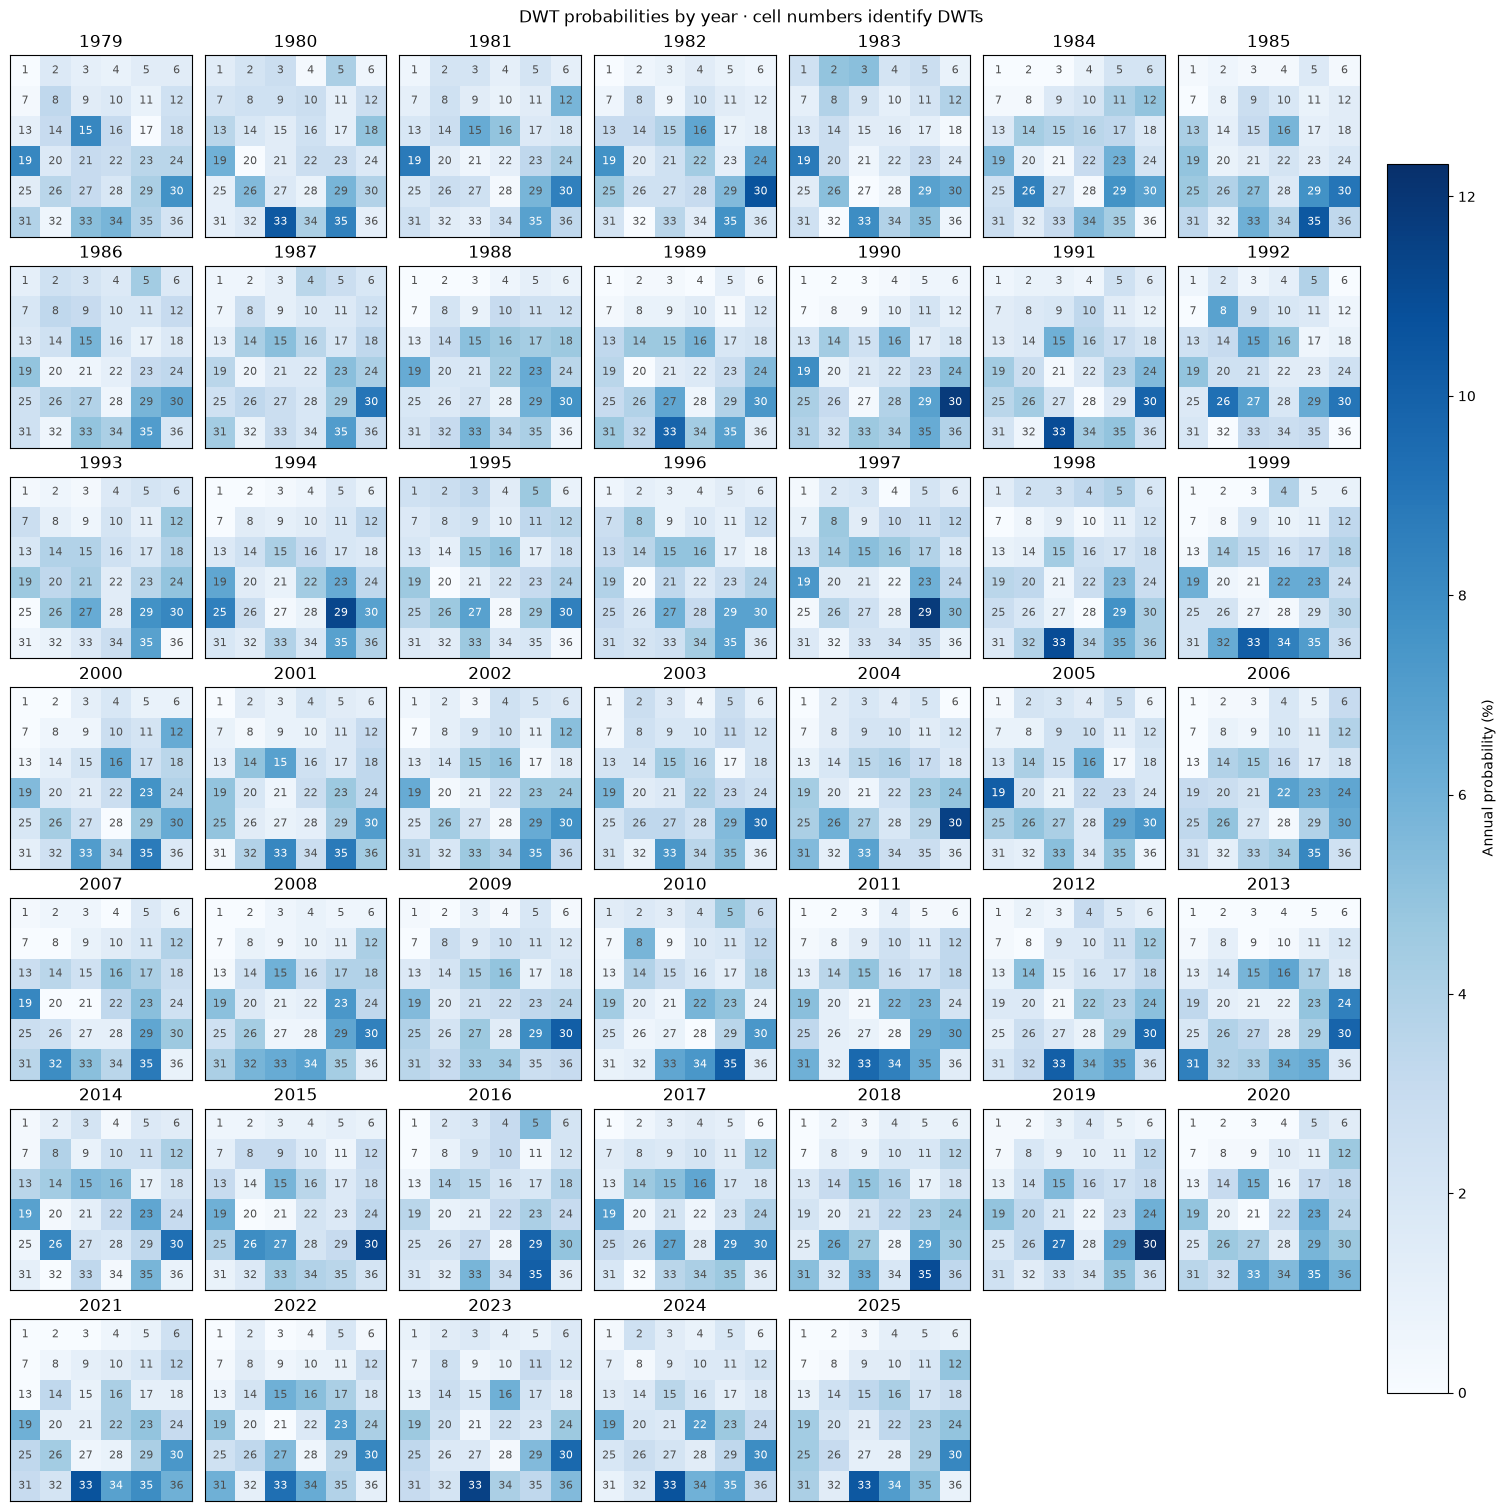

In [3]:
annual_figures = plot_annual_probabilities(annual_probability)
plt.show()


## Annual probability anomalies

Annual probability minus the full-record (1979–2025) probability for each DWT, in percentage points. The reference weights every classified day equally. Red indicates more frequent occurrence and blue less frequent occurrence. All panels share a symmetric color scale centered on zero.


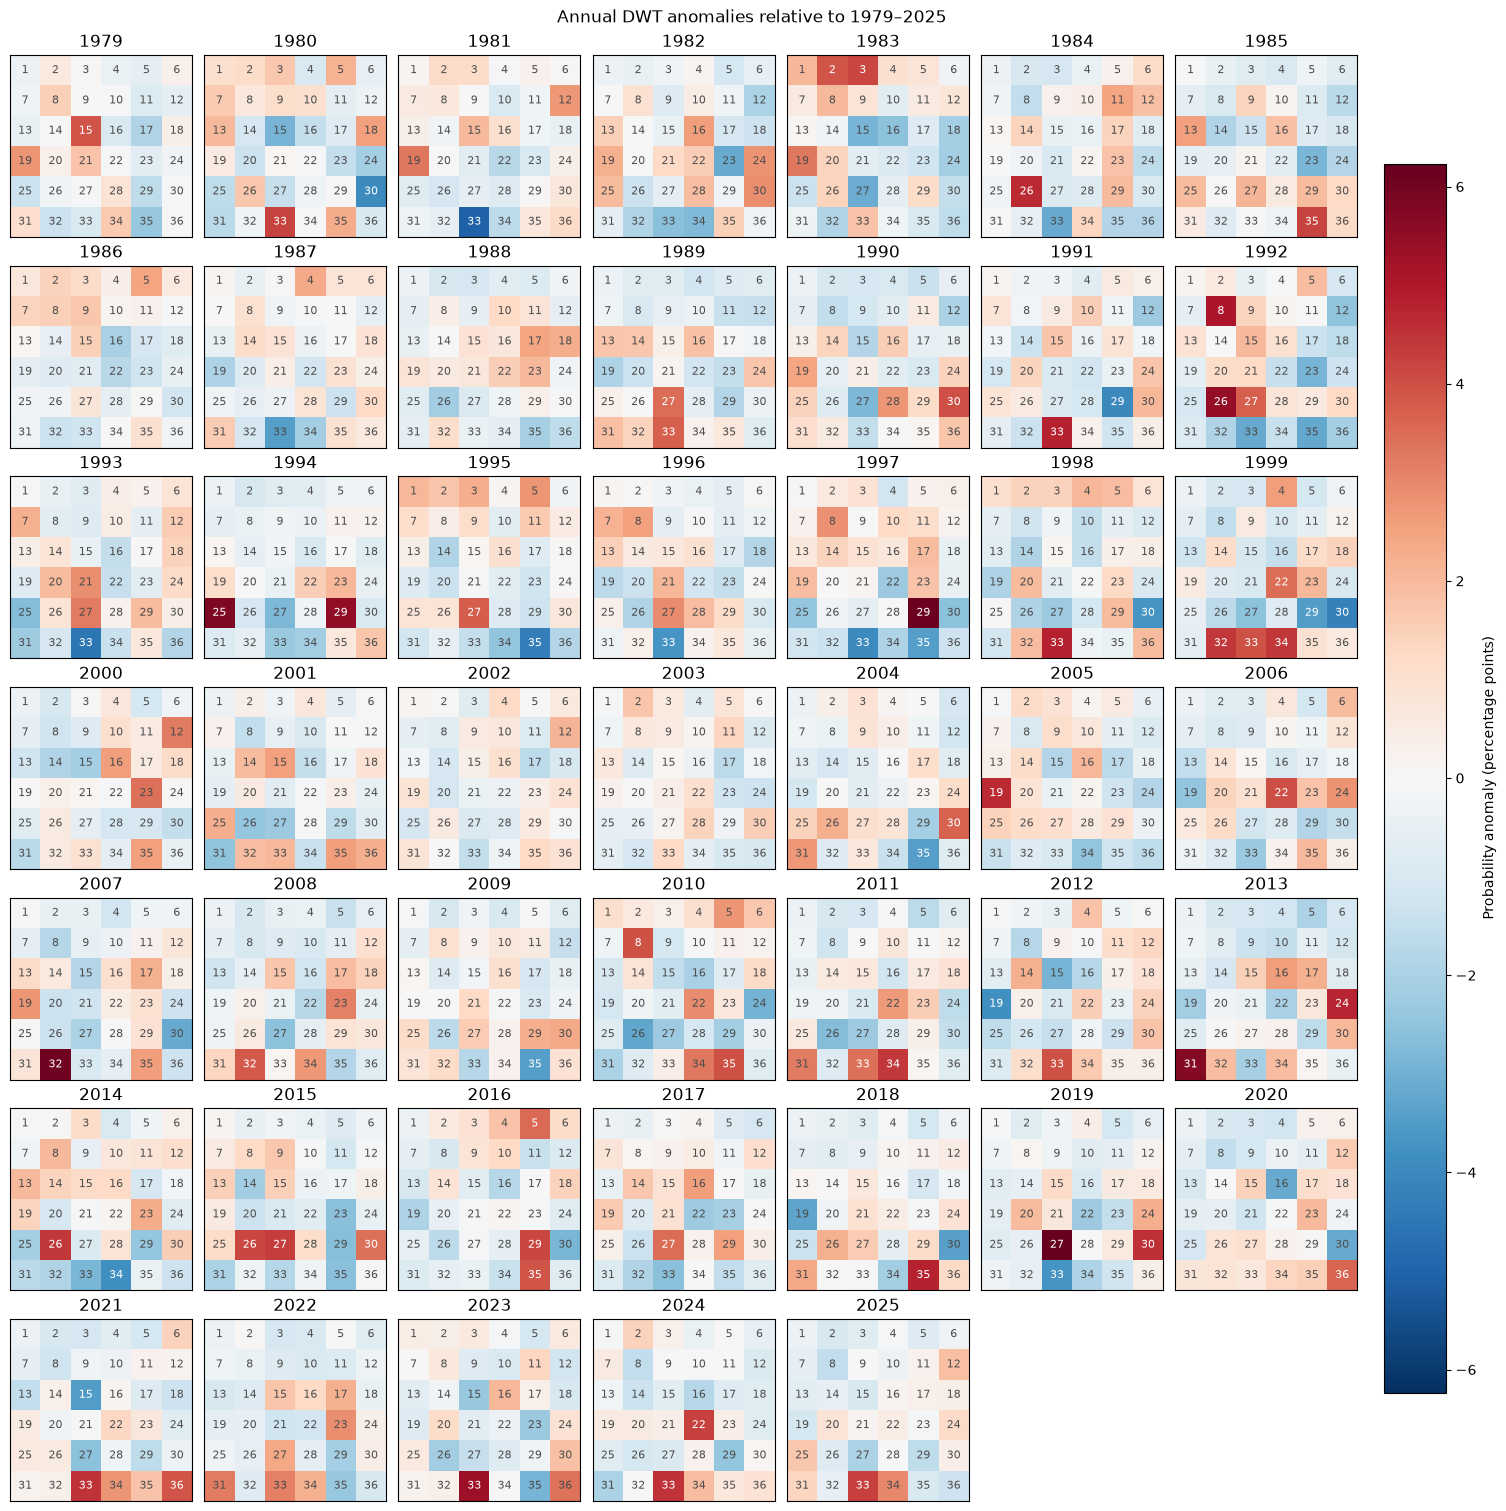

In [4]:
# Reference probabilities pool all classified days in 1979–2025.
climatology = annual_counts.sum(axis=0) / valid_days.sum()
annual_anomaly = annual_probability.subtract(climatology, axis="columns") * 100
np.testing.assert_allclose(annual_anomaly.loc[valid_days.gt(0)].sum(axis=1), 0, atol=1e-10)
anomaly_figures = plot_annual_anomalies(annual_anomaly)
plt.show()


## PCA of annual DWT probability anomalies

Use `bluemath_tk.datamining.pca.PCA` with years as observations and the 36 DWTs as features. Set `scale_data=False` to preserve the relative variance of anomalies in percentage points (covariance PCA). PCA centers each feature over the included years. Years with missing probabilities are excluded, not filled with zeros.

The first five EOFs retain the original 6 × 6 DWT layout. Each adjacent curve is its annual PC score; the title gives explained variance. EOF signs are arbitrary; interpret each EOF together with its PC.


In [5]:
import xarray as xr
from bluemath_tk.datamining.pca import PCA

pca_anomalies = annual_anomaly.dropna(axis=0, how="any")
if min(pca_anomalies.shape) < 5:
    raise ValueError("At least five complete years and five DWTs are needed.")
dwt_pca_input = xr.Dataset({
    "probability_anomaly": (("year", "dwt"), pca_anomalies.to_numpy()),
}, coords={"year": pca_anomalies.index.to_numpy(), "dwt": dwt_ids.to_numpy()})
dwt_pca_input.probability_anomaly.attrs["units"] = "percentage points"

N_PCS = 3
annual_dwt_pca = PCA(n_components=N_PCS)
annual_dwt_pcs = annual_dwt_pca.fit_transform(
    data=dwt_pca_input,
    vars_to_stack=["probability_anomaly"],
    coords_to_stack=["dwt"],
    pca_dim_for_rows="year",
    scale_data=False,
)
annual_dwt_eofs = annual_dwt_pca.eofs.probability_anomaly
print(f"First five modes explain {annual_dwt_pca.explained_variance_ratio.sum():.1%} of annual anomaly variance")


Using 36 out of 36 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
Data is not standarized


First five modes explain 44.9% of annual anomaly variance


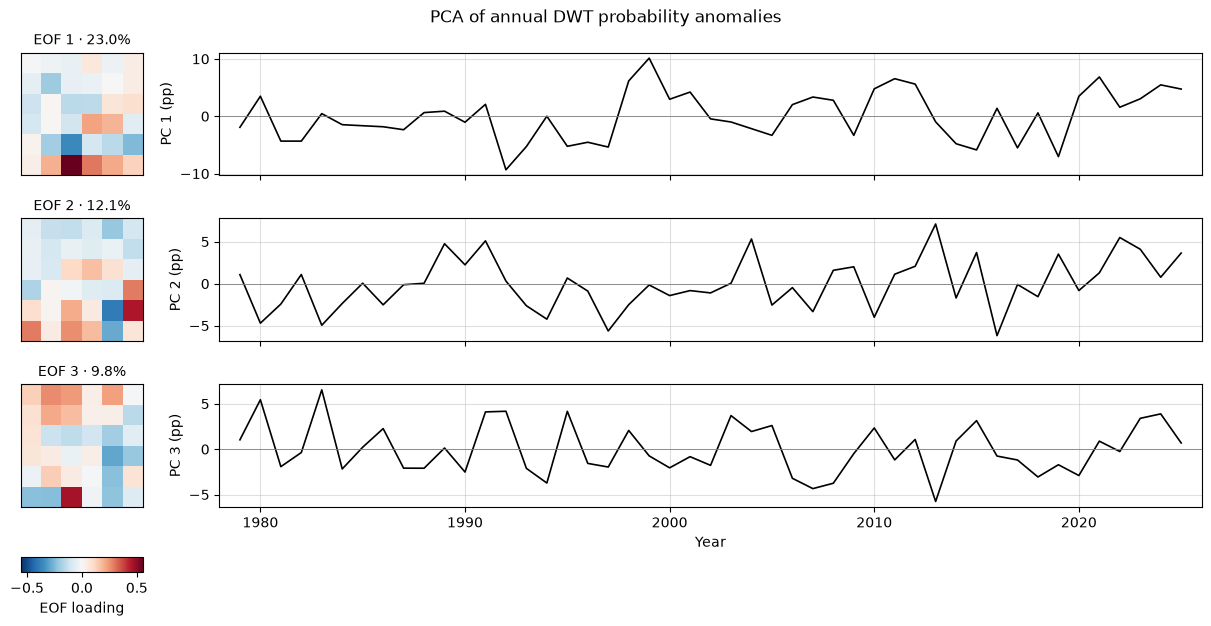

In [6]:
fig_pca, axes_pca = plot_pca_modes(
    annual_dwt_pcs, annual_dwt_eofs, annual_dwt_pca.explained_variance_ratio, dwt_ids,
)
plt.show()


## Five clusters of years using BlueMath KMeans

Cluster years using their first five DWT PC scores with `bluemath_tk.datamining.kma.KMA`. Scores retain their original scale (`normalize_data=False`), preserving the variance weighting of the retained PCA subspace. Use a fixed seed and 50 initializations.

Each year has one cluster color, repeated in all five PC panels. Cluster numbers are arbitrary; for reproducible display they are ordered by centroid value along DWT PC1. The maps on the left are EOFs, not cluster centroids.


In [7]:
from bluemath_tk.datamining.kma import KMA
from IPython.display import display

annual_cluster_input = pd.DataFrame(
    annual_dwt_pcs.PCs.values, index=annual_dwt_pcs.year.values,
    columns=[f"PC{i + 1}" for i in range(annual_dwt_pcs.sizes["n_component"])],
)
N_clusters = 5
annual_cluster_input.index.name = "year"
annual_kma = KMA(num_clusters=N_clusters, seed=42)
annual_kma.kma.set_params(n_init=50)
cluster_assignments, _ = annual_kma.fit_predict(
    data=annual_cluster_input.copy(), normalize_data=False,
)
cluster_order = annual_kma.centroids["PC1"].sort_values().index
cluster_mapping = {old: new for new, old in enumerate(cluster_order, start=1)}
year_clusters = cluster_assignments["kma_bmus"].map(cluster_mapping).rename("cluster")
cluster_colors = {1: "#0072B2", 2: "#E69F00", 3: "#009E73", 4: "#CC79A7", 5: "#D55E00"}
assert year_clusters.notna().all() and year_clusters.nunique() == N_clusters
cluster_summary = pd.DataFrame({
    "n_years": year_clusters.value_counts().sort_index(),
    "years": year_clusters.groupby(year_clusters).apply(lambda group: ", ".join(map(str, group.index))),
})
display(cluster_summary)


,n_years,years
cluster,,
1,18,"1979, 1981, 1982, 1985, 1986, 1987, 1992, 1993..."
2,6,"1989, 1991, 2004, 2013, 2022, 2023"
3,12,"1984, 1988, 1990, 1994, 2000, 2002, 2006, 2007..."
4,3,"1980, 1983, 2010"
5,8,"1998, 1999, 2001, 2011, 2012, 2021, 2024, 2025"


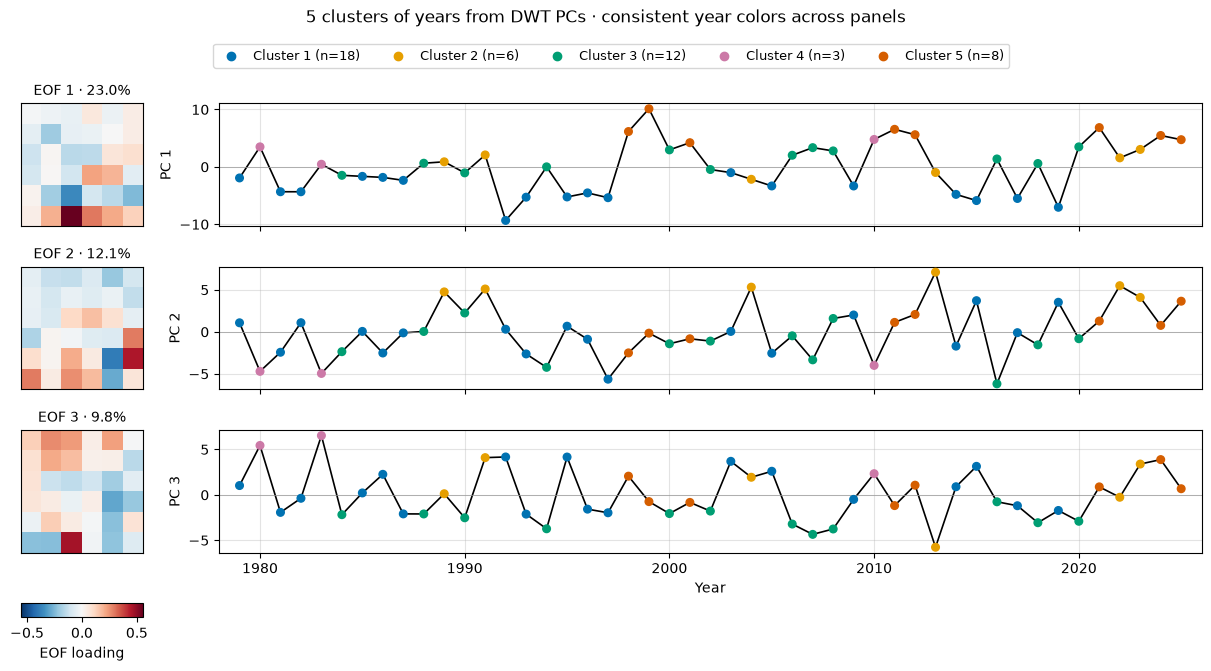

In [8]:
fig_year_clusters, axes_year_clusters = plot_year_clusters(
    annual_cluster_input, annual_dwt_eofs, annual_dwt_pca.explained_variance_ratio,
    dwt_ids, year_clusters, cluster_colors,
)
plt.show()


## Pairwise PCs by year cluster

All unique PC pairs in a triangular grid. Each point is one year; colors match the five KMeans clusters above.

Shaded envelopes are convex hulls with a small rounded outward buffer in normalized PC coordinates. They enclose the observed years; they are not confidence regions.


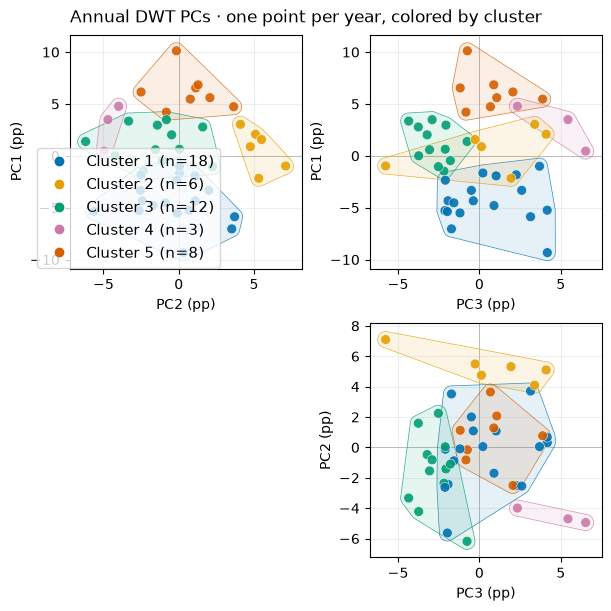

In [9]:
HULL_PADDING = 0.04  # Rounded margin as a fraction of each PC range.
fig_pc_pairs, axes_pc_pairs = plot_pc_pairs(
    annual_cluster_input, year_clusters, cluster_colors, hull_padding=HULL_PADDING,
)
plt.show()


In [10]:
# Export the annual DWT PCs for the sea-level regression notebook.
pc_output_path = repo_root / "toolkit/regression/outputs/annual_dwt_pcs.nc"
pc_output_path.parent.mkdir(parents=True, exist_ok=True)
exported_pcs = annual_dwt_pcs.copy()
exported_pcs["explained_variance_ratio"] = ("n_component", annual_dwt_pca.explained_variance_ratio)
exported_pcs.attrs.update(
    source_notebook="MMSL_regression.ipynb", source_model=str(dwt_path),
    description="Annual DWT probability anomaly PCA; calendar years; no feature scaling",
    pc_units="percentage points", annual_alignment="January through December",
)
exported_pcs.to_netcdf(pc_output_path)
print(f"Saved annual DWT PCs: {pc_output_path.name}")

Saved annual DWT PCs: annual_dwt_pcs.nc


## AWT centroids: mean DWT probabilities

For each year cluster (AWT), average the original annual DWT probabilities across its member years, giving each year equal weight. These are probability composites, not EOFs or reconstructed PCA centroids. Each 6 × 6 map sums to 100%; cell labels identify DWTs.


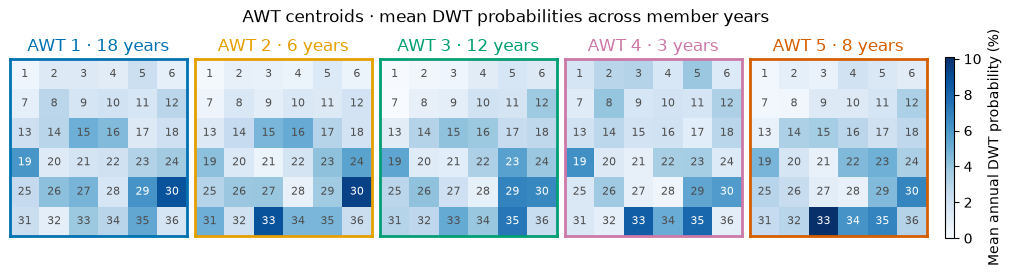

In [11]:
# AWT centroids in probability space: each member year has equal weight.
awt_membership = year_clusters.reindex(annual_probability.index)
if awt_membership.isna().any():
    raise ValueError("Every annual probability field must have an AWT assignment.")
awt_probability_centroids = annual_probability.groupby(awt_membership).mean()
awt_probability_centroids.index.name = "AWT"
awt_year_counts = awt_membership.value_counts().sort_index()
np.testing.assert_allclose(awt_probability_centroids.sum(axis=1), 1.0)

fig_awt_centroids, axes_awt_centroids = plot_awt_centroids(
    awt_probability_centroids, dwt_ids, awt_year_counts, cluster_colors,
)
plt.show()


## AWT centroid anomalies

Subtract the mean annual DWT probability across all years from each AWT probability centroid, weighting years equally in both. Colors show percentage-point differences: red means more frequent and blue less frequent than the reference. Each anomaly map sums to zero.


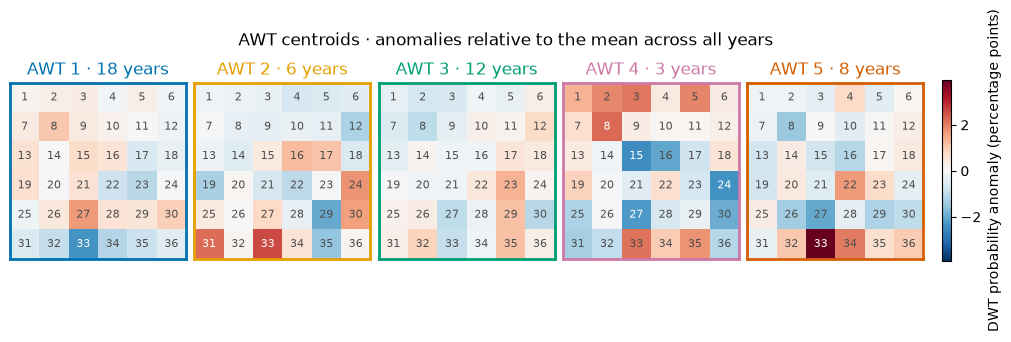

In [12]:
# Equal-year reference, consistent with the probability centroid definition.
awt_reference_probability = annual_probability.mean(axis=0)
awt_anomaly_centroids = awt_probability_centroids.subtract(awt_reference_probability, axis="columns")
np.testing.assert_allclose(awt_anomaly_centroids.sum(axis=1), 0, atol=1e-12)

fig_awt_anomalies, axes_awt_anomalies = plot_awt_anomalies(
    awt_anomaly_centroids, dwt_ids, awt_year_counts, cluster_colors,
)
plt.show()
